In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os

os.listdir()

['.ipynb_checkpoints',
 '.venv',
 'Churn.ipynb',
 'churn_analysis.ipynb',
 'customer_churn.db',
 'customer_churn_data_raw.xlsx',
 'Data Analytics Project -Churn Analysis Report (1).pdf']

In [3]:
os.listdir()

['.ipynb_checkpoints',
 '.venv',
 'Churn.ipynb',
 'churn_analysis.ipynb',
 'customer_churn.db',
 'customer_churn_data_raw.xlsx',
 'Data Analytics Project -Churn Analysis Report (1).pdf']

In [4]:
excel_file = pd.ExcelFile("customer_churn_data_raw.xlsx")

excel_file.sheet_names

['db_customer', 'db_subscription', 'db_support']

In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [6]:
customer_df = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name="db_customer"
)

customer_df.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [7]:
# Check the size and structure of the customer table
print("Shape:", customer_df.shape)
print("\nData types:")
print(customer_df.dtypes)

Shape: (21, 8)

Data types:
customerid               str
name                     str
country                  str
state                    str
gender                   str
dob           datetime64[us]
interests                str
pincode              float64
dtype: object


In [8]:
# Check for missing values in each customer field
customer_df.isna().sum()

customerid     0
name           0
country        3
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64

In [9]:
# Check whether any customer records are duplicated
customer_df.duplicated().sum()

np.int64(0)

In [10]:
# Load the subscription table for churn-related information
subscription_df = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name="db_subscription"
)

# Preview the subscription records
subscription_df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [11]:
# Check the size and structure of the subscription table
print("Shape:", subscription_df.shape)
print("\nData types:")
print(subscription_df.dtypes)

Shape: (21, 11)

Data types:
customerid                     str
subscription_start_date        str
subscription_type              str
renewal_date                   str
plan_type                      str
contract_type                  str
cancellation_date              str
cancellation_reason            str
monthly_charges            float64
cltv                         int64
churn_score                  int64
dtype: object


In [12]:
# Check missing values in the subscription table
subscription_df.isna().sum()

customerid                  0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason        15
monthly_charges             0
cltv                        0
churn_score                 0
dtype: int64

In [13]:
# Check for duplicate subscription records
subscription_df.duplicated().sum()

np.int64(0)

In [14]:
# Load the support table to examine customer service interactions
support_df = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name="db_support"
)

# Preview the support records
support_df.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,NaN,NaN
3,0013-MHZWF,2025-03-18,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,NaN,NaN


In [15]:
# Check the size and structure of the support table
print("Shape:", support_df.shape)
print("\nData types:")
print(support_df.dtypes)

Shape: (9, 6)

Data types:
customerid                   str
complaint_date    datetime64[us]
escalations                  str
csat_score                 int64
col_1                    float64
comment                      str
dtype: object


In [16]:
# Check missing values in the support table
support_df.isna().sum()

customerid        0
complaint_date    0
escalations       0
csat_score        0
col_1             9
comment           5
dtype: int64

In [17]:
# Check for duplicate support records
support_df.duplicated().sum()

np.int64(0)

In [18]:
# Convert subscription date fields to datetime
date_columns = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

for col in date_columns:
    subscription_df[col] = pd.to_datetime(
        subscription_df[col],
        errors="coerce"
    )

# Create the actual churn indicator from cancellation status
subscription_df["churned"] = subscription_df["cancellation_date"].notna().astype(int)

# Remove the completely empty support column
support_df = support_df.drop(columns=["col_1"])

# Check the updated subscription structure
subscription_df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churned
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [19]:
# Summarize the observed churn outcome
churn_summary = subscription_df["churned"].value_counts()

print("Customers who churned:", churn_summary.get(1, 0))
print("Customers who stayed:", churn_summary.get(0, 0))
print("Observed churn rate:", round(subscription_df["churned"].mean() * 100, 1), "%")

Customers who churned: 6
Customers who stayed: 15
Observed churn rate: 28.6 %


In [20]:
# Confirm the date fields were converted correctly
print(subscription_df[date_columns].dtypes)

subscription_start_date    datetime64[us]
renewal_date               datetime64[us]
cancellation_date          datetime64[us]
dtype: object


In [21]:
# Combine customer profile and subscription information
analysis_df = pd.merge(
    customer_df,
    subscription_df,
    on="customerid",
    how="left"
)

# Check the resulting structure
print("Shape:", analysis_df.shape)
analysis_df.head()

Shape: (21, 19)


,customerid,name,country,state,gender,dob,interests,pincode,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churned
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [22]:
# Confirm each customer appears only once after merging
print("Unique customers:", analysis_df["customerid"].nunique())
print("Total rows:", len(analysis_df))

Unique customers: 21
Total rows: 21


In [23]:
# Calculate the number and percentage of churned vs. retained customers
churn_breakdown = (
    analysis_df["churned"]
    .value_counts()
    .rename(index={0: "Stayed", 1: "Churned"})
)

churn_percent = (
    analysis_df["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: "Stayed", 1: "Churned"})
    .round(1)
)

print("Customer Count:")
print(churn_breakdown)

print("\nCustomer Percentage:")
print(churn_percent)

Customer Count:
churned
Stayed     15
Churned     6
Name: count, dtype: int64

Customer Percentage:
churned
Stayed     71.4
Churned    28.6
Name: proportion, dtype: float64


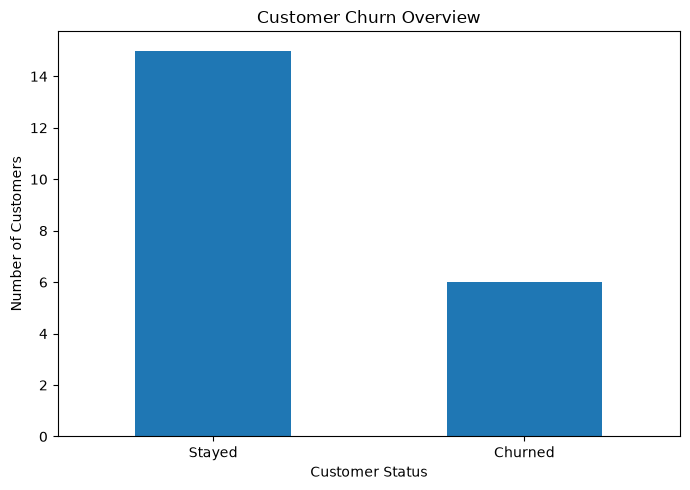

In [24]:
# Visualize the overall churn situation
plt.figure(figsize=(7, 5))

churn_breakdown.plot(kind="bar")

plt.title("Customer Churn Overview")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Calculate churn rate for each contract type
contract_churn = (
    analysis_df.groupby("contract_type")["churned"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customers",
        "sum": "churned_customers",
        "mean": "churn_rate"
    })
)

# Convert churn rate to percentage
contract_churn["churn_rate"] = (
    contract_churn["churn_rate"] * 100
).round(1)

contract_churn

,customers,churned_customers,churn_rate
contract_type,,,
Annual,12,1,8.3
Monthly,9,5,55.6


In [28]:
# Import Plotly for interactive visualizations
import plotly.express as px

print("Plotly is ready!")

Plotly is ready!


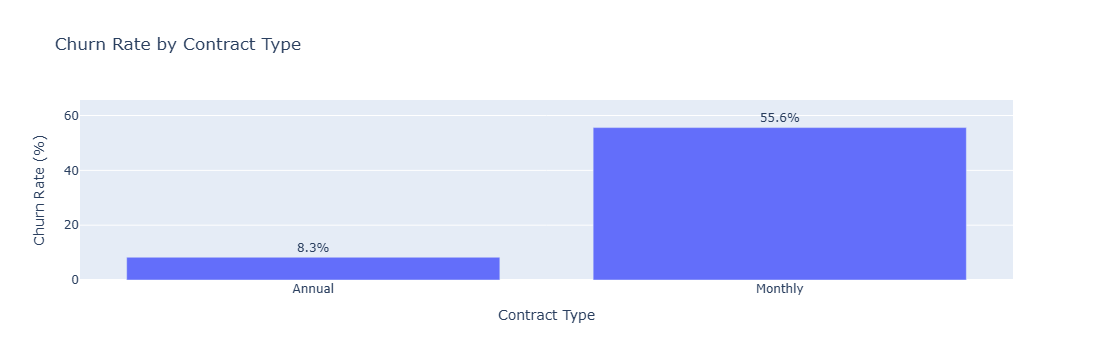

In [29]:
# Create an interactive comparison of churn rates by contract type

fig = px.bar(
    contract_churn.reset_index(),
    x="contract_type",
    y="churn_rate",
    text="churn_rate",
    title="Churn Rate by Contract Type",
    labels={
        "contract_type": "Contract Type",
        "churn_rate": "Churn Rate (%)"
    },
    hover_data=["customers", "churned_customers"]
)

fig.update_traces(
    texttemplate="%{text}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Churn Rate (%)",
    xaxis_title="Contract Type"
)

fig.show()

In [30]:
# Calculate churn rate by subscription plan
plan_churn = (
    analysis_df.groupby("plan_type")["churned"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customers",
        "sum": "churned_customers",
        "mean": "churn_rate"
    })
)

# Convert churn rate to percentage
plan_churn["churn_rate"] = (
    plan_churn["churn_rate"] * 100
).round(1)

plan_churn

,customers,churned_customers,churn_rate
plan_type,,,
Basic,5,3,60.0
Premium,7,1,14.3
Standard,9,2,22.2


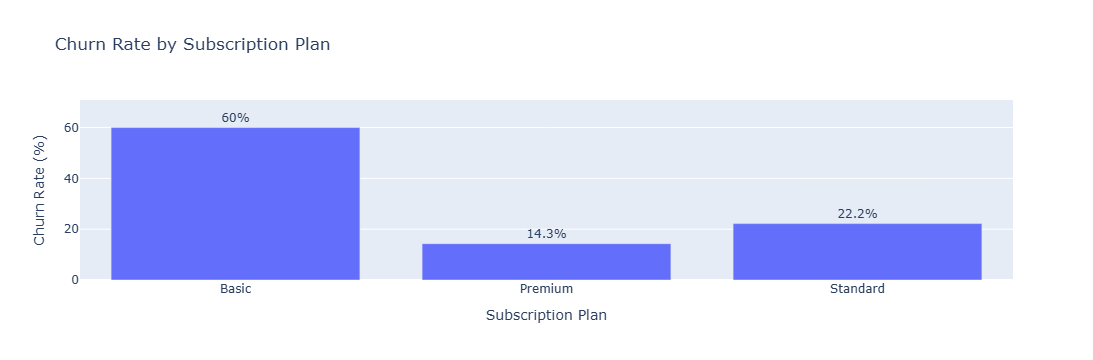

In [31]:
# Compare churn rates across subscription plans
fig = px.bar(
    plan_churn.reset_index(),
    x="plan_type",
    y="churn_rate",
    text="churn_rate",
    title="Churn Rate by Subscription Plan",
    labels={
        "plan_type": "Subscription Plan",
        "churn_rate": "Churn Rate (%)"
    },
    hover_data=["customers", "churned_customers"]
)

fig.update_traces(
    texttemplate="%{text}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Subscription Plan",
    yaxis_title="Churn Rate (%)"
)

fig.show()

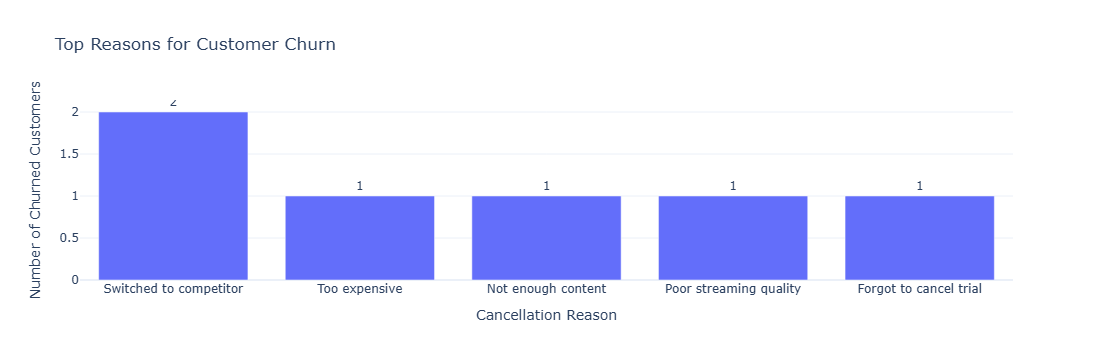

In [32]:
# Analyze the main reasons customers cancelled their subscriptions

cancelled_customers = subscription_df[
    subscription_df["churned"] == 1
].copy()

cancellation_reasons = (
    cancelled_customers["cancellation_reason"]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = ["Cancellation Reason", "Customers"]

fig = px.bar(
    cancellation_reasons,
    x="Cancellation Reason",
    y="Customers",
    text="Customers",
    title="Top Reasons for Customer Churn"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Cancellation Reason",
    yaxis_title="Number of Churned Customers",
    template="plotly_white"
)

fig.show()

In [33]:
# Compare churn scores between customers who stayed and those who churned

churn_score_summary = (
    subscription_df.groupby("churned")["churn_score"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

churn_score_summary["Customer Status"] = churn_score_summary["churned"].map({
    0: "Stayed",
    1: "Churned"
})

print(churn_score_summary[[
    "Customer Status", "count", "mean", "median"
]])

  Customer Status  count  mean  median
0          Stayed     15  26.2    22.0
1         Churned      6  86.0    85.5


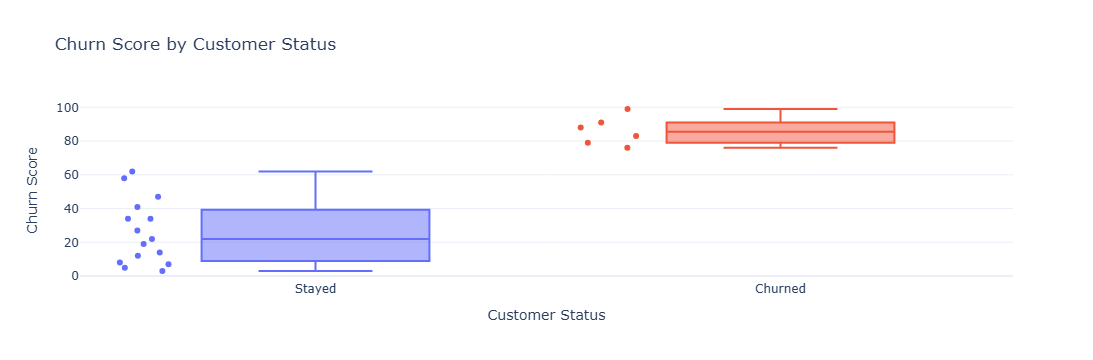

In [34]:
# Visualize how churn scores differ between stayed and churned customers

fig = px.box(
    subscription_df,
    x="churned",
    y="churn_score",
    color="churned",
    points="all",
    title="Churn Score by Customer Status",
    labels={
        "churned": "Customer Status",
        "churn_score": "Churn Score"
    }
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Stayed", "Churned"]
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.show()

In [35]:
# Connect support interactions to each customer's churn status

support_churn = support_df.merge(
    subscription_df[["customerid", "churned"]],
    on="customerid",
    how="left"
)

print(support_churn.head())

   customerid complaint_date escalations  csat_score            comment  \
0  0003-MKNFE     2024-08-28           N          60      service issue   
1  0003-MKNFE     2024-08-28           Y          10     demaned refund   
2  0013-EXCHZ     2024-01-20           Y          20                NaN   
3  0013-MHZWF     2025-03-18           N          90  guidance to renew   
4  0013-SMEOE     2024-11-01           N          30                NaN   

   churned  
0        1  
1        1  
2        1  
3        0  
4        1  


In [36]:
# Compare average customer satisfaction between churned and retained customers

csat_summary = (
    support_churn.groupby("churned")["csat_score"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

csat_summary["Customer Status"] = csat_summary["churned"].map({
    0: "Stayed",
    1: "Churned"
})

print(csat_summary[[
    "Customer Status", "count", "mean", "median"
]])

  Customer Status  count    mean  median
0          Stayed      1  90.000    90.0
1         Churned      8  34.375    27.5


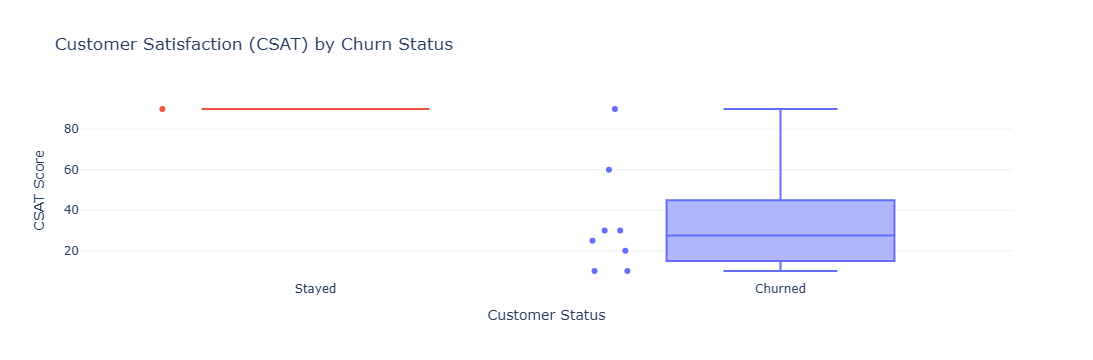

In [37]:
# Visualize customer satisfaction by churn status

fig = px.box(
    support_churn,
    x="churned",
    y="csat_score",
    color="churned",
    points="all",
    title="Customer Satisfaction (CSAT) by Churn Status",
    labels={
        "churned": "Customer Status",
        "csat_score": "CSAT Score"
    }
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Stayed", "Churned"]
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.show()


In [38]:
# Compare customer lifetime value between retained and churned customers

cltv_summary = (
    subscription_df.groupby("churned")["cltv"]
    .agg(["count", "mean", "median", "sum"])
    .reset_index()
)

cltv_summary["Customer Status"] = cltv_summary["churned"].map({
    0: "Stayed",
    1: "Churned"
})

print(cltv_summary[[
    "Customer Status", "count", "mean", "median", "sum"
]])

  Customer Status  count         mean  median    sum
0          Stayed     15  1016.466667   790.0  15247
1         Churned      6   341.166667   212.5   2047


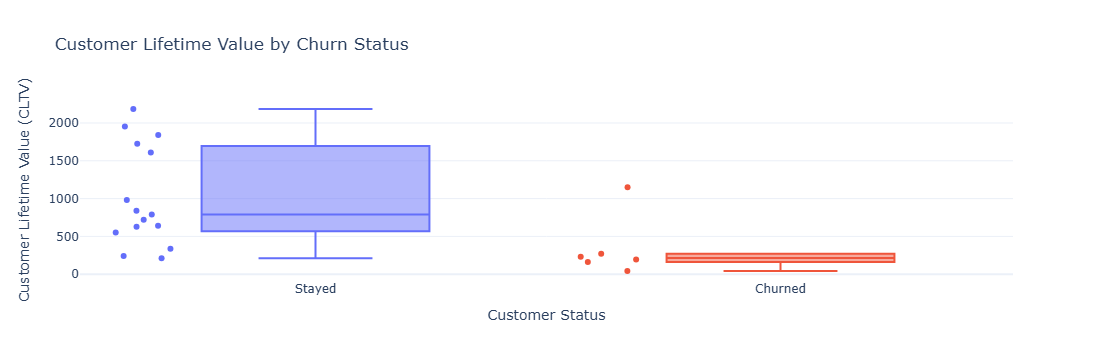

In [39]:
# Visualize customer lifetime value by churn status

fig = px.box(
    subscription_df,
    x="churned",
    y="cltv",
    color="churned",
    points="all",
    title="Customer Lifetime Value by Churn Status",
    labels={
        "churned": "Customer Status",
        "cltv": "Customer Lifetime Value (CLTV)"
    }
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Stayed", "Churned"]
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.show()

In [40]:
# Compare customer counts and churn rates by contract type

contract_summary = (
    subscription_df.groupby("contract_type")["churned"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_summary.columns = [
    "Contract Type",
    "Customers",
    "Churned Customers",
    "Churn Rate"
]

contract_summary["Churn Rate"] = (
    contract_summary["Churn Rate"] * 100
).round(1)

print(contract_summary)

  Contract Type  Customers  Churned Customers  Churn Rate
0        Annual         12                  1         8.3
1       Monthly          9                  5        55.6


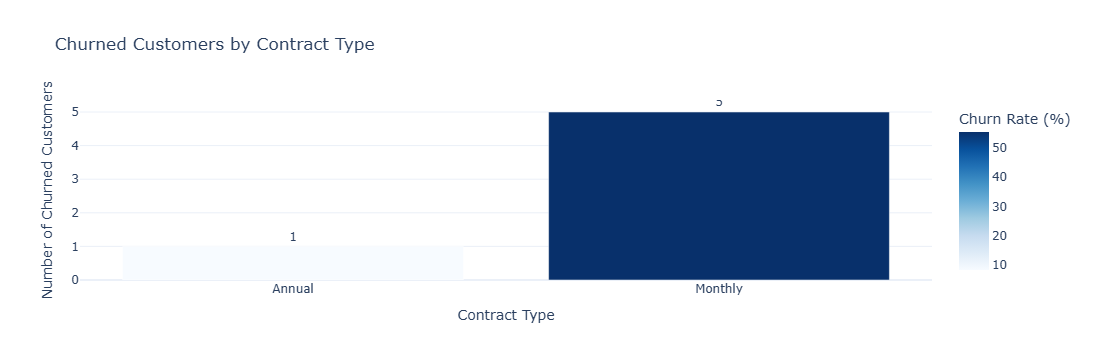

In [41]:
# Show both churn volume and churn rate by contract type

fig = px.bar(
    contract_summary,
    x="Contract Type",
    y="Churned Customers",
    text="Churned Customers",
    color="Churn Rate",
    color_continuous_scale="Blues",
    title="Churned Customers by Contract Type",
    hover_data={
        "Customers": True,
        "Churned Customers": True,
        "Churn Rate": True
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Contract Type",
    yaxis_title="Number of Churned Customers",
    coloraxis_colorbar_title="Churn Rate (%)"
)

fig.show()

In [44]:
# Aggregate support activity to one record per customer
support_summary = (
    support_df.groupby("customerid")
    .agg(
        complaints=("customerid", "size"),
        escalations=("escalations", lambda x: (x == "Y").sum()),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
)

# Bring churn status into the support summary
support_summary = support_summary.merge(
    subscription_df[["customerid", "churned"]],
    on="customerid",
    how="left"
)

# Create a readable customer status label
support_summary["Customer Status"] = support_summary["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

support_summary

,customerid,complaints,escalations,avg_csat,churned,Customer Status
0,0003-MKNFE,2,1,35.0,1,Churned
1,0013-EXCHZ,1,1,20.0,1,Churned
2,0013-MHZWF,1,0,90.0,0,Stayed
3,0013-SMEOE,1,0,30.0,1,Churned
4,0017-IUDMW,1,1,25.0,1,Churned
5,0019-EFAEP,1,1,30.0,1,Churned
6,0022-TCJCI,2,1,50.0,1,Churned


In [45]:
# Compare support activity between customers who stayed and churned
support_comparison = (
    support_summary.groupby("Customer Status")
    .agg(
        customers=("customerid", "count"),
        avg_complaints=("complaints", "mean"),
        avg_escalations=("escalations", "mean"),
        avg_csat=("avg_csat", "mean")
    )
    .round(2)
    .reset_index()
)

support_comparison

,Customer Status,customers,avg_complaints,avg_escalations,avg_csat
0,Churned,6,1.33,0.83,31.67
1,Stayed,1,1.00,0.00,90.00


In [46]:
# Compare churn rates across customer acquisition sources
acquisition_churn = (
    subscription_df.groupby("subscription_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

# Convert churn rate to percentage
acquisition_churn["churn_rate"] = acquisition_churn["churn_rate"] * 100

acquisition_churn

,subscription_type,customers,churned_customers,churn_rate
0,Organic,9,0,0.000000
1,Paid,6,1,16.666667
2,Refferal,6,5,83.333333


In [47]:
# Standardize the referral source spelling
subscription_df["subscription_type"] = subscription_df["subscription_type"].replace(
    {"Refferal": "Referral"}
)

# Confirm the cleaned categories
subscription_df["subscription_type"].value_counts()

subscription_type
Organic     9
Referral    6
Paid        6
Name: count, dtype: int64

In [48]:
# Measure each acquisition source's contribution to total churn
acquisition_churn["churn_contribution"] = (
    acquisition_churn["churned_customers"]
    / acquisition_churn["churned_customers"].sum()
    * 100
).round(1)

acquisition_churn

,subscription_type,customers,churned_customers,churn_rate,churn_contribution
0,Organic,9,0,0.000000,0.0
1,Paid,6,1,16.666667,16.7
2,Refferal,6,5,83.333333,83.3


In [49]:
# Recalculate acquisition churn using the cleaned source categories
acquisition_churn = (
    subscription_df.groupby("subscription_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

# Calculate each source's contribution to total churn
acquisition_churn["churn_rate"] = (
    acquisition_churn["churn_rate"] * 100
).round(1)

acquisition_churn["churn_contribution"] = (
    acquisition_churn["churned_customers"]
    / acquisition_churn["churned_customers"].sum()
    * 100
).round(1)

acquisition_churn

,subscription_type,customers,churned_customers,churn_rate,churn_contribution
0,Organic,9,0,0.0,0.0
1,Paid,6,1,16.7,16.7
2,Referral,6,5,83.3,83.3


In [50]:
# Count churned customers by cancellation month
monthly_churn = (
    subscription_df[subscription_df["churned"] == 1]
    .groupby(
        subscription_df.loc[
            subscription_df["churned"] == 1,
            "cancellation_date"
        ].dt.to_period("M")
    )
    .size()
    .reset_index(name="churned_customers")
)

# Convert the month back to a date for plotting
monthly_churn["month"] = monthly_churn["cancellation_date"].dt.to_timestamp()

monthly_churn

,cancellation_date,churned_customers,month
0,2024-02,1,2024-02-01
1,2024-05,1,2024-05-01
2,2024-09,2,2024-09-01
3,2024-10,1,2024-10-01
4,2024-11,1,2024-11-01


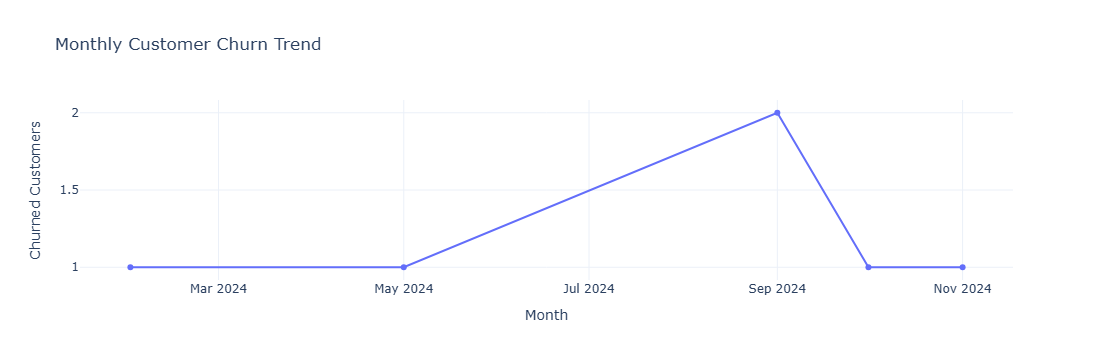

In [51]:
# Plot the monthly churn trend
fig = px.line(
    monthly_churn,
    x="month",
    y="churned_customers",
    markers=True,
    title="Monthly Customer Churn Trend",
    labels={
        "month": "Month",
        "churned_customers": "Churned Customers"
    }
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Churned Customers"
)

fig.show()

In [52]:
# Combine subscription and support information for customer-level risk analysis
risk_df = subscription_df.merge(
    support_summary[
        ["customerid", "complaints", "escalations", "avg_csat"]
    ],
    on="customerid",
    how="left"
)

# Fill missing support activity for customers with no recorded complaints
risk_df[["complaints", "escalations"]] = risk_df[
    ["complaints", "escalations"]
].fillna(0)

# Create a simple risk flag based on the strongest churn indicators
risk_df["High Risk"] = (
    (risk_df["churn_score"] >= 70) |
    (
        (risk_df["contract_type"] == "Monthly") &
        (risk_df["churn_score"] >= 50)
    )
)

# Rank customers by churn score
risk_df = risk_df.sort_values(
    by="churn_score",
    ascending=False
)

risk_df.head(10)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churned,complaints,escalations,avg_csat,High Risk
18,0022-TCJCI,2023-09-14,Referral,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99,1,2.0,1.0,50.0,True
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,2.0,1.0,35.0,True
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,1.0,1.0,20.0,True
11,0017-IUDMW,2023-03-17,Referral,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,83,1,1.0,1.0,25.0,True
6,0013-SMEOE,2021-09-30,Referral,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,1.0,0.0,30.0,True
13,0019-EFAEP,2022-08-25,Referral,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,76,1,1.0,1.0,30.0,True
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,NaN,20.99,550,62,0,0.0,0.0,NaN,False
15,0020-INWCK,2023-05-06,Organic,2025-05-06,Standard,Monthly,NaT,NaN,13.99,640,58,0,0.0,0.0,NaN,True
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,13.99,790,47,0,0.0,0.0,NaN,False
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0,0.0,0.0,NaN,False


In [53]:
# Select the fields needed for the retention risk table
risk_table = risk_df[
    [
        "customerid",
        "plan_type",
        "contract_type",
        "subscription_type",
        "churn_score",
        "cltv",
        "complaints",
        "escalations",
        "avg_csat",
        "churned",
        "High Risk"
    ]
].copy()

# Add a readable customer status
risk_table["Customer Status"] = risk_table["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

# Display the highest-risk customers first
risk_table[
    [
        "customerid",
        "plan_type",
        "contract_type",
        "churn_score",
        "cltv",
        "complaints",
        "escalations",
        "avg_csat",
        "Customer Status",
        "High Risk"
    ]
].head(10)

,customerid,plan_type,contract_type,churn_score,cltv,complaints,escalations,avg_csat,Customer Status,High Risk
18,0022-TCJCI,Basic,Monthly,99,42,2.0,1.0,50.0,Churned,True
1,0003-MKNFE,Premium,Annual,91,1150,2.0,1.0,35.0,Churned,True
4,0013-EXCHZ,Standard,Monthly,88,195,1.0,1.0,20.0,Churned,True
11,0017-IUDMW,Standard,Monthly,83,270,1.0,1.0,25.0,Churned,True
6,0013-SMEOE,Basic,Monthly,79,230,1.0,0.0,30.0,Churned,True
13,0019-EFAEP,Basic,Monthly,76,160,1.0,1.0,30.0,Churned,True
16,0020-JDNXP,Premium,Annual,62,550,0.0,0.0,NaN,Stayed,False
15,0020-INWCK,Standard,Monthly,58,640,0.0,0.0,NaN,Stayed,True
20,0023-UYUPN,Standard,Monthly,47,790,0.0,0.0,NaN,Stayed,False
9,0016-QLJIS,Basic,Annual,41,335,0.0,0.0,NaN,Stayed,False


In [54]:
# Prepare contract-level churn rates for visualization
contract_churn = (
    subscription_df.groupby("contract_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

# Convert churn rate to percentage
contract_churn["churn_rate"] = (
    contract_churn["churn_rate"] * 100
).round(1)

contract_churn

,contract_type,customers,churned_customers,churn_rate
0,Annual,12,1,8.3
1,Monthly,9,5,55.6


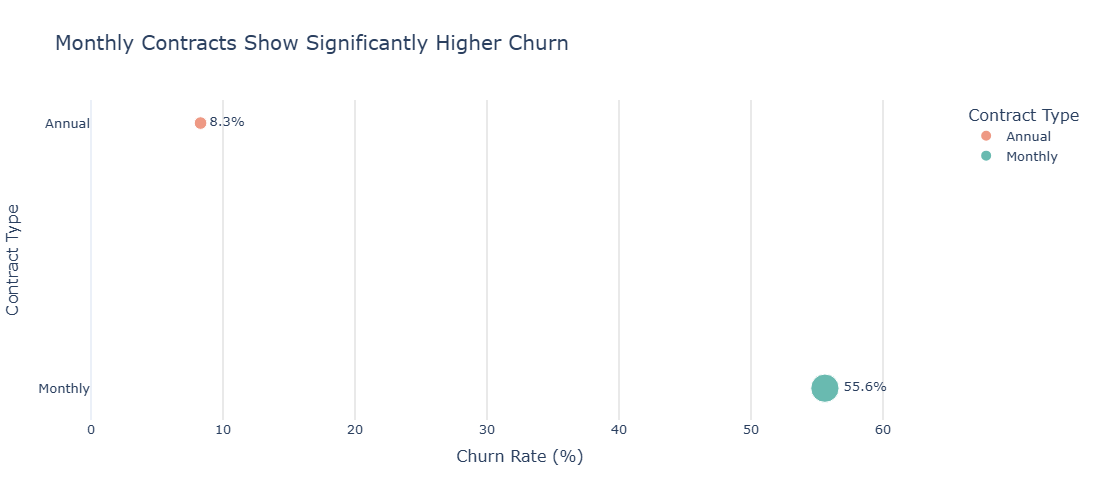

In [55]:
# Create an interactive lollipop-style churn comparison
fig = px.scatter(
    contract_churn,
    x="churn_rate",
    y="contract_type",
    size="churned_customers",
    color="contract_type",
    text="churn_rate",
    hover_data={
        "customers": True,
        "churned_customers": True,
        "churn_rate": ":.1f",
        "contract_type": False
    },
    title="Monthly Contracts Show Significantly Higher Churn",
    labels={
        "churn_rate": "Churn Rate (%)",
        "contract_type": "Contract Type"
    },
    color_discrete_sequence=["#E76F51", "#2A9D8F"]
)

# Format the chart for a clean portfolio presentation
fig.update_traces(
    texttemplate="%{text}%",
    textposition="middle right",
    marker=dict(
        line=dict(width=1)
    )
)

fig.update_layout(
    template="plotly_white",
    height=500,
    font=dict(size=13),
    title=dict(
        font=dict(size=20)
    ),
    xaxis=dict(
        range=[0, 65],
        showgrid=True,
        gridcolor="lightgray"
    ),
    yaxis=dict(
        showgrid=False
    ),
    legend_title_text="Contract Type"
)

fig.show()

In [56]:
# Create the final interactive churn charts and save them to the project folder

import os
import plotly.express as px
import plotly.graph_objects as go

# Create a folder for the final charts
charts_folder = os.path.join(os.getcwd(), "final_charts")
os.makedirs(charts_folder, exist_ok=True)

# Common chart styling: clean background with no gridlines
def clean_chart(fig, title):
    fig.update_layout(
        title=dict(
            text=title,
            x=0.03,
            xanchor="left",
            font=dict(size=24)
        ),
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(
            family="Arial",
            size=14,
            color="#17324D"
        ),
        xaxis=dict(
            showgrid=False,
            zeroline=False
        ),
        yaxis=dict(
            showgrid=False,
            zeroline=False
        ),
        hoverlabel=dict(
            bgcolor="white",
            font_size=13
        ),
        margin=dict(l=70, r=50, t=80, b=70)
    )
    
    return fig


# ============================================================
# 1. CHURN RATE BY CONTRACT TYPE — BUBBLE CHART
# ============================================================

contract_summary = (
    subscription_df.groupby("contract_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

contract_summary["churn_rate"] = (
    contract_summary["churned_customers"]
    / contract_summary["customers"] * 100
)

fig1 = px.scatter(
    contract_summary,
    x="churn_rate",
    y="contract_type",
    size="customers",
    color="contract_type",
    text=contract_summary["churn_rate"].round(1).astype(str) + "%",
    color_discrete_sequence=["#F28E8B", "#48B5A9"],
    labels={
        "churn_rate": "Churn Rate (%)",
        "contract_type": "Contract Type"
    },
    hover_data={
        "customers": True,
        "churned_customers": True,
        "churn_rate": ":.1f"
    }
)

fig1.update_traces(
    textposition="middle right",
    marker=dict(line=dict(width=1.5, color="white"))
)

fig1 = clean_chart(
    fig1,
    "Monthly Contracts Show Significantly Higher Churn"
)

fig1.write_html(
    os.path.join(charts_folder, "01_contract_type_churn.html"),
    include_plotlyjs=True
)


# ============================================================
# 2. CHURN RATE BY SUBSCRIPTION PLAN — LOLLIPOP CHART
# ============================================================

plan_summary = (
    subscription_df.groupby("plan_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

plan_summary["churn_rate"] = (
    plan_summary["churned_customers"]
    / plan_summary["customers"] * 100
)

# Sort plans from lowest to highest churn
plan_summary = plan_summary.sort_values("churn_rate")

fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="lines",
        line=dict(color="#D8DDE6", width=6),
        hoverinfo="skip"
    )
)

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="markers+text",
        marker=dict(
            size=22,
            color=["#4FB3BF", "#F4A261", "#E76F51"],
            line=dict(width=2, color="white")
        ),
        text=plan_summary["churn_rate"].round(1).astype(str) + "%",
        textposition="middle right",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Churn Rate: %{x:.1f}%<br>"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

fig2.update_layout(
    xaxis_title="Churn Rate (%)",
    yaxis_title="Subscription Plan"
)

fig2 = clean_chart(
    fig2,
    "Basic Plan Customers Have the Highest Churn Risk"
)

fig2.write_html(
    os.path.join(charts_folder, "02_subscription_plan_churn.html"),
    include_plotlyjs=True
)


# ============================================================
# 3. CHURN SCORE BY CUSTOMER STATUS — BOX + POINTS
# ============================================================

score_df = subscription_df.copy()

score_df["Customer Status"] = score_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig3 = px.box(
    score_df,
    x="Customer Status",
    y="churn_score",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#5B6CFF",
        "Churned": "#F06A4F"
    },
    labels={
        "churn_score": "Churn Score",
        "Customer Status": "Customer Status"
    }
)

fig3 = clean_chart(
    fig3,
    "Churned Customers Show Consistently Higher Churn Scores"
)

fig3.write_html(
    os.path.join(charts_folder, "03_churn_score_status.html"),
    include_plotlyjs=True
)


# ============================================================
# 4. CUSTOMER SATISFACTION BY CHURN STATUS
# ============================================================

csat_df = support_summary.dropna(subset=["avg_csat"]).copy()

fig4 = px.box(
    csat_df,
    x="Customer Status",
    y="avg_csat",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#4FB3BF",
        "Churned": "#E76F51"
    },
    labels={
        "avg_csat": "Average CSAT Score",
        "Customer Status": "Customer Status"
    }
)

fig4 = clean_chart(
    fig4,
    "Customer Satisfaction Is Lower Among Churned Customers"
)

fig4.write_html(
    os.path.join(charts_folder, "04_csat_churn_status.html"),
    include_plotlyjs=True
)


# ============================================================
# 5. CUSTOMER LIFETIME VALUE BY CHURN STATUS
# ============================================================

cltv_df = subscription_df.copy()

cltv_df["Customer Status"] = cltv_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig5 = px.box(
    cltv_df,
    x="Customer Status",
    y="cltv",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#457B9D",
        "Churned": "#E76F51"
    },
    labels={
        "cltv": "Customer Lifetime Value (CLTV)",
        "Customer Status": "Customer Status"
    }
)

fig5 = clean_chart(
    fig5,
    "Churned Customers Have Much Lower Customer Lifetime Value"
)

fig5.write_html(
    os.path.join(charts_folder, "05_cltv_churn_status.html"),
    include_plotlyjs=True
)


# ============================================================
# 6. MONTHLY CHURN TREND — LINE CHART
# ============================================================

monthly_churn = (
    subscription_df[
        subscription_df["churned"] == 1
    ]
    .dropna(subset=["cancellation_date"])
    .assign(
        Month=lambda x: x["cancellation_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month")
    .size()
    .reset_index(name="Churned Customers")
    .sort_values("Month")
)

fig6 = px.line(
    monthly_churn,
    x="Month",
    y="Churned Customers",
    markers=True,
    text="Churned Customers"
)

fig6.update_traces(
    line=dict(color="#9B5DE5", width=4),
    marker=dict(
        size=11,
        color="#F15BB5",
        line=dict(width=2, color="white")
    ),
    textposition="top center"
)

fig6.update_xaxes(
    tickformat="%b %Y",
    showgrid=False
)

fig6 = clean_chart(
    fig6,
    "Monthly Customer Churn Shows Periodic Spikes"
)

fig6.write_html(
    os.path.join(charts_folder, "06_monthly_churn_trend.html"),
    include_plotlyjs=True
)


# ============================================================
# CONFIRM ALL FILES WERE CREATED
# ============================================================

print("Final charts created successfully!")
print()
print("Location:", charts_folder)
print()
print("Files created:")

for file in sorted(os.listdir(charts_folder)):
    print("✓", file)

Task was destroyed but it is pending!
task: <Task pending name='Task-374' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-375' coro=<Kernel.shell_main() running at C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Lib\site-packages\_plotly_utils\utils.py:513: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  class _Chomper:
Task was destroyed but it is pending!
task: <Task pending name='Task-375' coro=<Kernel.shell_main() running at C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Lib\site-packages\ipykernel

Final charts created successfully!

Location: C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\final_charts

Files created:
✓ 01_contract_type_churn.html
✓ 02_subscription_plan_churn.html
✓ 03_churn_score_status.html
✓ 04_csat_churn_status.html
✓ 05_cltv_churn_status.html
✓ 06_monthly_churn_trend.html


# Key Insights & Business Story

The analysis shows that customer churn is concentrated around a few clear risk patterns rather than being evenly distributed across the customer base.

### 1. Churn is strongly associated with monthly contracts

The overall churn rate is 28.6%, but customers on monthly contracts have a churn rate of 55.6%, compared with only 8.3% for annual contracts. This suggests that customers without a longer-term commitment are considerably more likely to leave.

### 2. The Basic plan has the highest churn rate

Basic plan customers have a 60.0% churn rate, compared with 22.2% for Standard and 14.3% for Premium. This makes the Basic plan an important area for further investigation, particularly around pricing, perceived value, and customer experience.

### 3. Churn risk is clearly reflected in the churn score

Churned customers have a much higher average churn score than customers who stayed. The median score was 85.5 for churned customers compared with 22.0 for customers who stayed. This indicates that the churn score is a strong indicator of observed customer risk in this dataset.

### 4. Churned customers represent much lower customer lifetime value

The median CLTV for customers who stayed was 790, compared with 212.5 for churned customers. While the business is losing customers with lower observed lifetime value, continued churn could still create a larger long-term revenue problem if the same pattern persists as the customer base grows.

### 5. Customer support interactions show signs of dissatisfaction

Churned customers with recorded support interactions had an average CSAT of 31.7 compared with 90.0 for the customer who stayed. Churned customers also recorded an average of 1.33 complaints and 0.83 escalations. This suggests that unresolved service issues may be associated with churn.

### 6. Referral customers account for most observed churn

Referral customers have the highest churn rate at 83.3% and account for 83.3% of all observed churn in this sample. This is an important finding, but the sample is small, so the business should investigate the referral customer journey before concluding that referrals inherently cause churn.

### 7. A small group of customers requires immediate attention

The customer-level risk analysis identified all six churned customers as high-risk based on their observed churn indicators. One additional customer who has stayed is also flagged as high risk because of a relatively high churn score and a monthly contract. This customer should be placed on a retention watchlist.

# Business Recommendations

Based on the analysis, the following actions should be prioritized:

### 1. Strengthen retention for monthly customers

Customers on monthly contracts should receive stronger retention interventions, such as renewal incentives, loyalty benefits, or targeted engagement before their next billing or renewal point.

### 2. Investigate the Basic plan

The Basic plan has the highest observed churn rate. The business should review its pricing, features, customer expectations, and perceived value to understand why customers on this plan are leaving.

### 3. Use churn scores to prioritize retention efforts

Customers with high churn scores should be reviewed before they leave. Rather than applying the same retention strategy to every customer, the business can prioritize customers showing the strongest risk signals.

### 4. Address support issues earlier

Customers with repeated complaints, escalations, or low CSAT should receive faster follow-up. Improving the resolution of support issues could help reduce dissatisfaction before it develops into churn.

### 5. Protect high-value customers

Although churned customers in this sample have lower CLTV overall, high-CLTV customers who show elevated churn risk should receive priority retention attention because losing valuable customers can have a larger financial impact.

### 6. Review the referral customer journey

Referral customers account for most observed churn in this sample. The business should investigate whether referred customers receive different expectations, onboarding experiences, or service outcomes compared with customers acquired through other channels.

# Conclusion

The analysis shows that customer churn is primarily concentrated around identifiable risk patterns. Monthly contracts, the Basic plan, high churn scores, support dissatisfaction, and the referral acquisition channel stand out as areas requiring attention.

The customer-level analysis further shows that the existing churn score can help prioritize retention efforts, with all observed churned customers falling into the high-risk group.

The key business opportunity is therefore not simply to measure how many customers are leaving, but to identify customers at risk early and intervene before churn occurs.

Because the dataset contains only 21 customers, these findings should be treated as directional rather than definitive. A larger dataset would allow the business to validate these patterns and develop a more robust predictive churn model.


In [57]:
pip install kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   --

In [58]:
# Export the final interactive charts as PNG images for GitHub
png_folder = os.path.join(charts_folder, "images")
os.makedirs(png_folder, exist_ok=True)

# Save each chart as a high-resolution PNG
fig1.write_image(os.path.join(png_folder, "01_contract_type_churn.png"), scale=2)
fig2.write_image(os.path.join(png_folder, "02_subscription_plan_churn.png"), scale=2)
fig3.write_image(os.path.join(png_folder, "03_churn_score_status.png"), scale=2)
fig4.write_image(os.path.join(png_folder, "04_csat_churn_status.png"), scale=2)
fig5.write_image(os.path.join(png_folder, "05_cltv_churn_status.png"), scale=2)
fig6.write_image(os.path.join(png_folder, "06_monthly_churn_trend.png"), scale=2)

print("PNG charts exported successfully!")
print("Saved to:", png_folder)

RuntimeError: 
Image export requires the Kaleido package, v1.0.0 or greater,
which can be installed using pip:

    $ pip install --upgrade "kaleido>=1"


In [59]:
pip install --upgrade "kaleido>=1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import tools needed to create and save the chart images
import os

# Create the image folder
png_folder = os.path.join(charts_folder, "images")
os.makedirs(png_folder, exist_ok=True)

# Export all six charts as high-resolution PNG files
fig1.write_image(os.path.join(png_folder, "01_contract_type_churn.png"), scale=2)
fig2.write_image(os.path.join(png_folder, "02_subscription_plan_churn.png"), scale=2)
fig3.write_image(os.path.join(png_folder, "03_churn_score_status.png"), scale=2)
fig4.write_image(os.path.join(png_folder, "04_csat_churn_status.png"), scale=2)
fig5.write_image(os.path.join(png_folder, "05_cltv_churn_status.png"), scale=2)
fig6.write_image(os.path.join(png_folder, "06_monthly_churn_trend.png"), scale=2)

print("PNG charts exported successfully!")
print("Saved to:", png_folder)


NameError: name 'charts_folder' is not defined

In [3]:
# Set up the chart export folder
import os

charts_folder = os.path.join(os.getcwd(), "final_charts")
png_folder = os.path.join(charts_folder, "images")

os.makedirs(png_folder, exist_ok=True)

# Export the six final charts as high-resolution PNGs
fig1.write_image(os.path.join(png_folder, "01_contract_type_churn.png"), scale=2)
fig2.write_image(os.path.join(png_folder, "02_subscription_plan_churn.png"), scale=2)
fig3.write_image(os.path.join(png_folder, "03_churn_score_status.png"), scale=2)
fig4.write_image(os.path.join(png_folder, "04_csat_churn_status.png"), scale=2)
fig5.write_image(os.path.join(png_folder, "05_cltv_churn_status.png"), scale=2)
fig6.write_image(os.path.join(png_folder, "06_monthly_churn_trend.png"), scale=2)

print("PNG charts exported successfully!")
print("Location:", png_folder)

NameError: name 'fig1' is not defined

In [4]:
# Recreate and export all six final churn charts
import os
import plotly.express as px
import plotly.graph_objects as go

# Create folders for interactive and image versions
charts_folder = os.path.join(os.getcwd(), "final_charts")
images_folder = os.path.join(charts_folder, "images")

os.makedirs(charts_folder, exist_ok=True)
os.makedirs(images_folder, exist_ok=True)


# ------------------------------------------------------------
# 1. Contract Type Churn — Bubble Chart
# ------------------------------------------------------------

contract_summary = (
    subscription_df.groupby("contract_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

contract_summary["churn_rate"] = (
    contract_summary["churned_customers"]
    / contract_summary["customers"] * 100
)

fig1 = px.scatter(
    contract_summary,
    x="churn_rate",
    y="contract_type",
    size="customers",
    color="contract_type",
    text=contract_summary["churn_rate"].round(1).astype(str) + "%",
    color_discrete_sequence=["#E76F51", "#2A9D8F"],
    labels={
        "churn_rate": "Churn Rate (%)",
        "contract_type": "Contract Type"
    },
    hover_data={
        "customers": True,
        "churned_customers": True,
        "churn_rate": ":.1f"
    }
)

fig1.update_traces(
    textposition="middle right",
    marker=dict(line=dict(width=1.5, color="white"))
)

fig1.update_layout(
    title="Monthly Contracts Show Significantly Higher Churn",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)

fig1.write_html(
    os.path.join(charts_folder, "01_contract_type_churn.html")
)
fig1.write_image(
    os.path.join(images_folder, "01_contract_type_churn.png"),
    scale=2
)


# ------------------------------------------------------------
# 2. Subscription Plan Churn — Lollipop Chart
# ------------------------------------------------------------

plan_summary = (
    subscription_df.groupby("plan_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

plan_summary["churn_rate"] = (
    plan_summary["churned_customers"]
    / plan_summary["customers"] * 100
)

plan_summary = plan_summary.sort_values("churn_rate")

fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="lines",
        line=dict(color="#D8DDE6", width=6),
        hoverinfo="skip"
    )
)

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="markers+text",
        marker=dict(
            size=22,
            color=["#4FB3BF", "#F4A261", "#E76F51"],
            line=dict(width=2, color="white")
        ),
        text=plan_summary["churn_rate"].round(1).astype(str) + "%",
        textposition="middle right",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Churn Rate: %{x:.1f}%<br>"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

fig2.update_layout(
    title="Basic Plan Customers Have the Highest Churn Risk",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title="Churn Rate (%)",
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="Subscription Plan",
        showgrid=False,
        zeroline=False
    ),
    height=500
)

fig2.write_html(
    os.path.join(charts_folder, "02_subscription_plan_churn.html")
)
fig2.write_image(
    os.path.join(images_folder, "02_subscription_plan_churn.png"),
    scale=2
)


# ------------------------------------------------------------
# 3. Churn Score by Customer Status — Box Plot
# ------------------------------------------------------------

score_df = subscription_df.copy()

score_df["Customer Status"] = score_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig3 = px.box(
    score_df,
    x="Customer Status",
    y="churn_score",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#5B6CFF",
        "Churned": "#F06A4F"
    },
    labels={
        "churn_score": "Churn Score",
        "Customer Status": "Customer Status"
    }
)

fig3.update_layout(
    title="Churned Customers Show Much Higher Churn Scores",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)

fig3.write_html(
    os.path.join(charts_folder, "03_churn_score_status.html")
)
fig3.write_image(
    os.path.join(images_folder, "03_churn_score_status.png"),
    scale=2
)


# ------------------------------------------------------------
# 4. CSAT by Customer Status — Box Plot
# ------------------------------------------------------------

csat_df = support_summary.dropna(
    subset=["avg_csat"]
).copy()

fig4 = px.box(
    csat_df,
    x="Customer Status",
    y="avg_csat",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#4FB3BF",
        "Churned": "#E76F51"
    },
    labels={
        "avg_csat": "Average CSAT Score",
        "Customer Status": "Customer Status"
    }
)

fig4.update_layout(
    title="Customer Satisfaction Is Lower Among Churned Customers",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)

fig4.write_html(
    os.path.join(charts_folder, "04_csat_churn_status.html")
)
fig4.write_image(
    os.path.join(images_folder, "04_csat_churn_status.png"),
    scale=2
)


# ------------------------------------------------------------
# 5. CLTV by Customer Status — Box Plot
# ------------------------------------------------------------

cltv_df = subscription_df.copy()

cltv_df["Customer Status"] = cltv_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig5 = px.box(
    cltv_df,
    x="Customer Status",
    y="cltv",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#457B9D",
        "Churned": "#E76F51"
    },
    labels={
        "cltv": "Customer Lifetime Value (CLTV)",
        "Customer Status": "Customer Status"
    }
)

fig5.update_layout(
    title="Churned Customers Have Much Lower Customer Lifetime Value",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)

fig5.write_html(
    os.path.join(charts_folder, "05_cltv_churn_status.html")
)
fig5.write_image(
    os.path.join(images_folder, "05_cltv_churn_status.png"),
    scale=2
)


# ------------------------------------------------------------
# 6. Monthly Churn Trend — Line Chart
# ------------------------------------------------------------

monthly_churn = (
    subscription_df[
        subscription_df["churned"] == 1
    ]
    .dropna(subset=["cancellation_date"])
    .assign(
        Month=lambda x:
        x["cancellation_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("Month")
    .size()
    .reset_index(name="Churned Customers")
    .sort_values("Month")
)

fig6 = px.line(
    monthly_churn,
    x="Month",
    y="Churned Customers",
    markers=True,
    text="Churned Customers"
)

fig6.update_traces(
    line=dict(color="#9B5DE5", width=4),
    marker=dict(
        size=11,
        color="#F15BB5",
        line=dict(width=2, color="white")
    ),
    textposition="top center"
)

fig6.update_layout(
    title="Monthly Customer Churn Shows Periodic Spikes",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title="Month",
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="Churned Customers",
        showgrid=False,
        zeroline=False
    ),
    height=500
)

fig6.write_html(
    os.path.join(charts_folder, "06_monthly_churn_trend.html")
)
fig6.write_image(
    os.path.join(images_folder, "06_monthly_churn_trend.png"),
    scale=2
)


# ------------------------------------------------------------
# Confirm everything was created
# ------------------------------------------------------------

print("✓ All six charts recreated successfully.")
print()
print("Interactive charts:")
for file in sorted(os.listdir(charts_folder)):
    if file.endswith(".html"):
        print("  ✓", file)

print()
print("PNG charts:")
for file in sorted(os.listdir(images_folder)):
    print("  ✓", file)

print()
print("Charts saved in:")
print(charts_folder)

NameError: name 'subscription_df' is not defined

In [5]:
# Reload the source data and rebuild the tables needed for the final charts

import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load the original Excel workbook
file_path = "customer_churn_data_raw.xlsx"

excel_data = pd.ExcelFile(file_path)

print("Available sheets:", excel_data.sheet_names)

Available sheets: ['db_customer', 'db_subscription', 'db_support']


In [6]:
# Load the three project tables from the Excel workbook

customer_df = pd.read_excel(file_path, sheet_name="db_customer")
subscription_df = pd.read_excel(file_path, sheet_name="db_subscription")
support_df = pd.read_excel(file_path, sheet_name="db_support")

# Convert subscription dates to datetime
date_columns = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

for column in date_columns:
    subscription_df[column] = pd.to_datetime(
        subscription_df[column],
        errors="coerce"
    )

# Standardize the subscription source label
subscription_df["subscription_type"] = (
    subscription_df["subscription_type"]
    .replace({"Refferal": "Referral"})
)

print("Customer table:", customer_df.shape)
print("Subscription table:", subscription_df.shape)
print("Support table:", support_df.shape)

Customer table: (21, 8)
Subscription table: (21, 11)
Support table: (9, 6)


In [7]:
# Summarize support activity at the customer level
support_summary = (
    support_df.groupby("customerid")
    .agg(
        complaints=("customerid", "size"),
        escalations=("escalations", lambda x: (x == "Y").sum()),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
)

# Add each customer's churn status
support_summary = support_summary.merge(
    subscription_df[["customerid", "churned"]],
    on="customerid",
    how="left"
)

# Create a readable customer status label
support_summary["Customer Status"] = support_summary["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

support_summary

KeyError: "['churned'] not in index"

In [8]:
# Create the churn indicator from cancellation status
subscription_df["churned"] = (
    subscription_df["cancellation_date"].notna().astype(int)
)

# Check the resulting churn counts
print(subscription_df["churned"].value_counts())

print("\nChurn rate:",
      round(subscription_df["churned"].mean() * 100, 1), "%")

churned
0    15
1     6
Name: count, dtype: int64

Churn rate: 28.6 %


In [9]:
# Summarize support activity at the customer level
support_summary = (
    support_df.groupby("customerid")
    .agg(
        complaints=("customerid", "size"),
        escalations=("escalations", lambda x: (x == "Y").sum()),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
)

# Add churn status to each customer's support record
support_summary = support_summary.merge(
    subscription_df[["customerid", "churned"]],
    on="customerid",
    how="left"
)

# Convert the churn indicator into a readable label
support_summary["Customer Status"] = support_summary["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

support_summary

,customerid,complaints,escalations,avg_csat,churned,Customer Status
0,0003-MKNFE,2,1,35.0,1,Churned
1,0013-EXCHZ,1,1,20.0,1,Churned
2,0013-MHZWF,1,0,90.0,0,Stayed
3,0013-SMEOE,1,0,30.0,1,Churned
4,0017-IUDMW,1,1,25.0,1,Churned
5,0019-EFAEP,1,1,30.0,1,Churned
6,0022-TCJCI,2,1,50.0,1,Churned


In [10]:
# Create and export the six final churn visualizations

import os
import plotly.express as px
import plotly.graph_objects as go

# Create folders for the chart files
charts_folder = os.path.join(os.getcwd(), "final_charts")
images_folder = os.path.join(charts_folder, "images")

os.makedirs(charts_folder, exist_ok=True)
os.makedirs(images_folder, exist_ok=True)


# 1. Contract Type Churn
contract_summary = (
    subscription_df.groupby("contract_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

contract_summary["churn_rate"] = (
    contract_summary["churned_customers"]
    / contract_summary["customers"] * 100
)

fig1 = px.scatter(
    contract_summary,
    x="churn_rate",
    y="contract_type",
    size="customers",
    color="contract_type",
    text=contract_summary["churn_rate"].round(1).astype(str) + "%",
    color_discrete_sequence=["#E76F51", "#2A9D8F"],
    labels={
        "churn_rate": "Churn Rate (%)",
        "contract_type": "Contract Type"
    }
)

fig1.update_traces(
    textposition="middle right",
    marker=dict(line=dict(width=1.5, color="white"))
)

fig1.update_layout(
    title="Monthly Contracts Show Higher Churn",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)


# 2. Subscription Plan Churn
plan_summary = (
    subscription_df.groupby("plan_type")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

plan_summary["churn_rate"] = (
    plan_summary["churned_customers"]
    / plan_summary["customers"] * 100
)

plan_summary = plan_summary.sort_values("churn_rate")

fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="lines",
        line=dict(width=6),
        hoverinfo="skip"
    )
)

fig2.add_trace(
    go.Scatter(
        x=plan_summary["churn_rate"],
        y=plan_summary["plan_type"],
        mode="markers+text",
        marker=dict(
            size=22,
            line=dict(width=2, color="white")
        ),
        text=plan_summary["churn_rate"].round(1).astype(str) + "%",
        textposition="middle right",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Churn Rate: %{x:.1f}%"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

fig2.update_layout(
    title="Basic Plan Has the Highest Churn Rate",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title="Churn Rate (%)",
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="Plan Type",
        showgrid=False,
        zeroline=False
    ),
    height=500
)


# 3. Churn Score by Customer Status
score_df = subscription_df.copy()

score_df["Customer Status"] = score_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig3 = px.box(
    score_df,
    x="Customer Status",
    y="churn_score",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#5B6CFF",
        "Churned": "#F06A4F"
    },
    labels={
        "churn_score": "Churn Score",
        "Customer Status": "Customer Status"
    }
)

fig3.update_layout(
    title="Churned Customers Have Higher Churn Scores",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)


# 4. CSAT by Customer Status
csat_df = support_summary.dropna(
    subset=["avg_csat"]
).copy()

fig4 = px.box(
    csat_df,
    x="Customer Status",
    y="avg_csat",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#4FB3BF",
        "Churned": "#E76F51"
    },
    labels={
        "avg_csat": "Average CSAT Score",
        "Customer Status": "Customer Status"
    }
)

fig4.update_layout(
    title="Churned Customers Show Lower Satisfaction",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)


# 5. CLTV by Customer Status
cltv_df = subscription_df.copy()

cltv_df["Customer Status"] = cltv_df["churned"].map(
    {0: "Stayed", 1: "Churned"}
)

fig5 = px.box(
    cltv_df,
    x="Customer Status",
    y="cltv",
    color="Customer Status",
    points="all",
    color_discrete_map={
        "Stayed": "#457B9D",
        "Churned": "#E76F51"
    },
    labels={
        "cltv": "Customer Lifetime Value",
        "Customer Status": "Customer Status"
    }
)

fig5.update_layout(
    title="Churned Customers Have Lower CLTV",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    height=500
)


# 6. Monthly Churn Trend
monthly_churn = (
    subscription_df[subscription_df["churned"] == 1]
    .dropna(subset=["cancellation_date"])
    .assign(
        Month=lambda x:
        x["cancellation_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("Month")
    .size()
    .reset_index(name="Churned Customers")
    .sort_values("Month")
)

fig6 = px.line(
    monthly_churn,
    x="Month",
    y="Churned Customers",
    markers=True,
    text="Churned Customers"
)

fig6.update_traces(
    line=dict(color="#9B5DE5", width=4),
    marker=dict(
        size=11,
        color="#F15BB5",
        line=dict(width=2, color="white")
    ),
    textposition="top center"
)

fig6.update_layout(
    title="Monthly Churn Trend",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        title="Month",
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="Churned Customers",
        showgrid=False,
        zeroline=False
    ),
    height=500
)


# Export all charts as interactive HTML and PNG files
figures = [fig1, fig2, fig3, fig4, fig5, fig6]

names = [
    "01_contract_type_churn",
    "02_subscription_plan_churn",
    "03_churn_score_status",
    "04_csat_churn_status",
    "05_cltv_churn_status",
    "06_monthly_churn_trend"
]

for figure, name in zip(figures, names):
    figure.write_html(
        os.path.join(charts_folder, f"{name}.html")
    )
    figure.write_image(
        os.path.join(images_folder, f"{name}.png"),
        scale=2
    )

print("✓ Six charts created successfully.")
print("✓ Interactive HTML files saved.")
print("✓ PNG files saved.")
print("✓ Gridlines removed.")
print("Chart folder:", charts_folder)

✓ Six charts created successfully.
✓ Interactive HTML files saved.
✓ PNG files saved.
✓ Gridlines removed.
Chart folder: C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\final_charts


In [11]:
# Import sys to identify the current Python environment
import sys

# Display the Python environment being used
print(sys.executable)

C:\Users\osomo\OneDrive\Documents\DATA\Churn Analysis\.venv\Scripts\python.exe


In [13]:
# Export the packages installed in the current virtual environment
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True
)

print(result.stdout)

anyio==4.15.1
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
arrow==1.4.0
asttokens==3.0.2
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.15.0
bleach==6.4.0
certifi==2026.7.22
cffi==2.1.1
charset-normalizer==3.5.1
choreographer==1.3.0
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.21
defusedxml==0.7.1
et_xmlfile==2.0.0
executing==2.2.1
fastjsonschema==2.22.2
fonttools==4.65.0
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.19
ipykernel==7.3.0
ipython==9.17.1
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.9
isoduration==20.11.0
jedi==0.20.0
Jinja2==3.1.6
json5==0.15.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.1
jupyter-lsp==2.3.1
jupyter_builder==1.2.3
jupyter_client==8.10.0
jupyter_core==5.9.1
jupyter_server==2.21.0
jupyter_server_terminals==0.5.4
jupyterlab==4.6.3
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
jupyterlab_widgets==3.

In [14]:
# Save the project's installed packages for reproducibility
requirements_path = "requirements.txt"

with open(requirements_path, "w") as file:
    file.write(result.stdout)

print("requirements.txt created successfully.")

requirements.txt created successfully.
